# Importation et définition de variables globales

In [11]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import ale_py
import gc
import seaborn as sns

from agent.rainbow_agent import DQNAgent as Rainbow

from agent.no_noisy_no_categ_agent import DQNAgent as NoNoisyNoCateg
from reseaux.nn_no_noisy_no_categ_no_duel import Network as NnNoThree
from reseaux.nn_no_noisy_no_categ import Network as NnDueling

from agent.no_noisy_agent import DQNAgent as NoNoisy
from reseaux.nn_no_noisy_no_duel import Network as NnCateg
from reseaux.nn_no_noisy import Network as NnNoNoisy

from utils.processing import show_latest_video

In [55]:
# Environment
env = gym.make("ALE/Freeway-v5", render_mode="rgb_array")

# Set random seed

In [56]:
seed = 777

def seed_torch(seed):
    torch.manual_seed(seed)
    if torch.backends.cudnn.enabled:
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

np.random.seed(seed)
random.seed(seed)
seed_torch(seed)

# Initialisation

In [57]:
# paramètres
num_frames = 3
memory_size = 100000 #ou 10 000 d'après le code original
batch_size = 128
target_update = 100
epsilon_decay = 1 / 2000

# Agent

GERER L'ASPECT VIDEO !!!!!

In [ ]:
#ordre : rainbow, no_three, no_noisy_no_categ, no_noisy_no_duel, no_noisy

score_agents = np.zeros([5, num_frames], dtype=float)

for iter in range(num_frames): 
    # Définition
    agent_rainbow = Rainbow(env, memory_size, batch_size, target_update, seed)
    agent_no_three = NoNoisyNoCateg(NnNoThree, env, memory_size, batch_size, target_update, epsilon_decay, seed)
    agent_no_noisy_no_categ = NoNoisyNoCateg(NnDueling, env, memory_size, batch_size, target_update, epsilon_decay, seed)
    agent_no_noisy_no_duel = NoNoisy(NnCateg, env, memory_size, batch_size, target_update,  epsilon_decay, seed)
    agent_no_noisy = NoNoisy(NnNoNoisy, env, memory_size, batch_size, target_update, epsilon_decay, seed)
    
    # Entraînement
    agent_rainbow.train(iter)
    agent_no_three.train(iter)
    agent_no_noisy_no_categ.train(iter)
    agent_no_noisy_no_duel.train(iter)
    agent_no_noisy.train(iter)

    # Test
    # Le traitement des vidéos se fait par
    score_agents[0][iter] = agent_rainbow.test("corbeille/")
    score_agents[1][iter] = agent_no_three.test("corbeille/")
    score_agents[2][iter] = agent_no_noisy_no_categ.test("corbeille/")
    score_agents[3][iter] = agent_no_noisy_no_duel.test("corbeille/")
    score_agents[4][iter] = agent_no_noisy.test("corbeille/")

    # Nettoyage mémoire
    agent_rainbow.cleanup()
    del agent_rainbow
    gc.collect()

    # Nettoyage mémoire
    agent_no_three.cleanup()
    del agent_no_three
    gc.collect()

    # Nettoyage mémoire
    agent_no_noisy_no_categ.cleanup()
    del agent_no_noisy_no_categ
    gc.collect()

    # Nettoyage mémoire
    agent_no_noisy_no_duel.cleanup()
    del agent_no_noisy_no_duel
    gc.collect()

    # Nettoyage mémoire
    agent_no_noisy.cleanup()
    del agent_no_noisy
    gc.collect()

In [7]:
import os
print(os.listdir())


['.git', '.gitignore', '.venv', 'agent', 'apply_rainbows.ipynb', 'best_videos', 'buffers', 'graph_rainbows.ipynb', 'Notebooks modèles', 'Rainbow-master', 'requirements.txt', 'reseaux', 'utils', 'videos', '__pycache__']


In [13]:
import pickle

# Charger le fichier localement
with open("ma_liste_0_199.pkl", "rb") as f:
    score_agents = pickle.load(f)

print("Liste chargée :", type(score_agents))  # Vérifie le type de l'objet

Liste chargée : <class 'numpy.ndarray'>


In [ ]:
score_agents

array([[ 0.00000e+00,  1.04500e+03, -1.99700e+01,  2.52460e+02,
        -2.79000e+00, -1.89300e+01,  5.30000e+01,  1.04500e+03,
         1.02054e+03,  2.64500e+01,  0.00000e+00, -2.04800e+01,
         2.59000e+02,  1.04500e+03,  1.04500e+03,  1.98290e+02,
         4.85220e+02,  2.26180e+02,  9.05750e+02,  2.30000e+00,
        -2.04800e+01, -2.04800e+01,  0.00000e+00, -2.04800e+01,
         1.04500e+03,  0.00000e+00,  1.03350e+03,  1.02100e+03,
        -2.04800e+01, -2.04800e+01, -2.00300e+01,  4.69710e+02,
        -2.04800e+01,  1.04500e+03, -2.04800e+01, -2.04800e+01,
         1.04500e+03, -1.18100e+01,  0.00000e+00,  0.00000e+00,
         1.04500e+03,  1.04500e+03, -8.00000e-02,  1.04500e+03,
         1.04294e+03,  1.04500e+03, -1.89500e+01, -2.04600e+01,
         0.00000e+00,  1.04500e+03, -3.09000e+00, -1.43600e+01,
        -1.94600e+01,  6.94500e+02, -1.19800e+01,  1.04050e+03,
        -2.04800e+01,  0.00000e+00, -2.04800e+01,  1.00000e+00,
         1.04500e+03,  0.00000e+00, -2.0

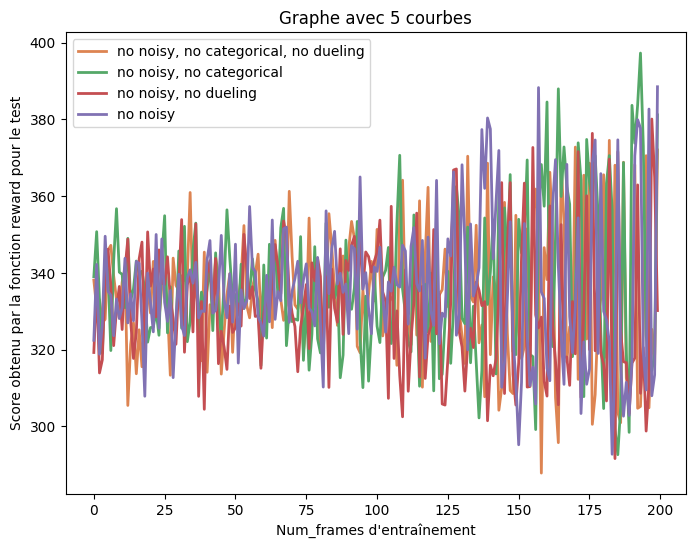

In [14]:
liste_frames = np.arange(200)
liste_label = ["rainbow", "no noisy, no categorical, no dueling", "no noisy, no categorical", "no noisy, no dueling", "no noisy"]
# Générer une palette de 5 couleurs harmonieuses
colors = sns.color_palette("deep", n_colors=len(liste_label))


# Création de la figure et du graphe
plt.figure(figsize=(8, 6))
plt.title("Graphe avec 5 courbes")

# Tracer les courbes
for i in range(1,len(liste_label)):
    plt.plot(liste_frames, score_agents[i], label=liste_label[i], color=colors[i], linewidth=2)

# Ajout de la légende et des labels
plt.xlabel("Num_frames d'entraînement") # QU EST CE QUE NUM FRAMES DANS TRAI?
plt.ylabel("Score obtenu par la fonction reward pour le test")
plt.legend()

# Affichage du graphe
plt.show()